# **Pronósticos basados en series de tiempo**

## - María del Carmen Sac
## - Juan Pablo Marroquín


##Ejercicio 3: Pronóstico de ocupados  *series de tiempo*



En este ejercicio se busca construir modelos de regresión para series de tiempo con el fin de encontrar el mejor pronóstico para la variable Ocupados, correspondiente al número de ocupados en miles de personas para las 13 principales ciudades.

Para ello, se evaluarán distintos modelos que incorporan componentes de tendencia y estacionalidad, incluyendo tendencia lineal, tendencia cuadrática y variables dummy estacionales. Posteriormente, los modelos serán comparados mediante métricas de error y análisis de residuales, con el propósito de seleccionar el modelo más adecuado para realizar pronósticos de los próximos seis meses.

## **1. Carga de paquetes**

In [90]:
#Librerías
import pandas as pd
import numpy as np

from statsmodels.sandbox.stats.runs import runstest_1samp   # prueba de rachas
import statsmodels.api as sm                                # Box-Pierce y Ljung-Box

from matplotlib import pyplot as plt
import pylab as py

from scipy import stats

from datetime import datetime
from dateutil.relativedelta import relativedelta

## **2. Carga de datos**

In [91]:
#Carga de datos
data = pd.read_excel(
    "https://raw.githubusercontent.com/dagudelo30/Series-de-tiempo---Javeriana-Cali/main/intro-moving_average/datosEmpleo.xlsx",
    index_col='mes',
    parse_dates=True
)

data.head()

,TD_13ciudades,Ocupados,Desocupados,Inactivos
mes,,,,
2001-01-01,20.946380,6923.604,1834.507,4600.718
2001-02-01,19.894213,7037.746,1747.820,4596.805
2001-03-01,19.221565,6945.973,1652.823,4807.120
2001-04-01,17.888575,6973.079,1519.137,4937.280
2001-05-01,17.945654,6994.462,1529.720,4928.911


(222, 4)


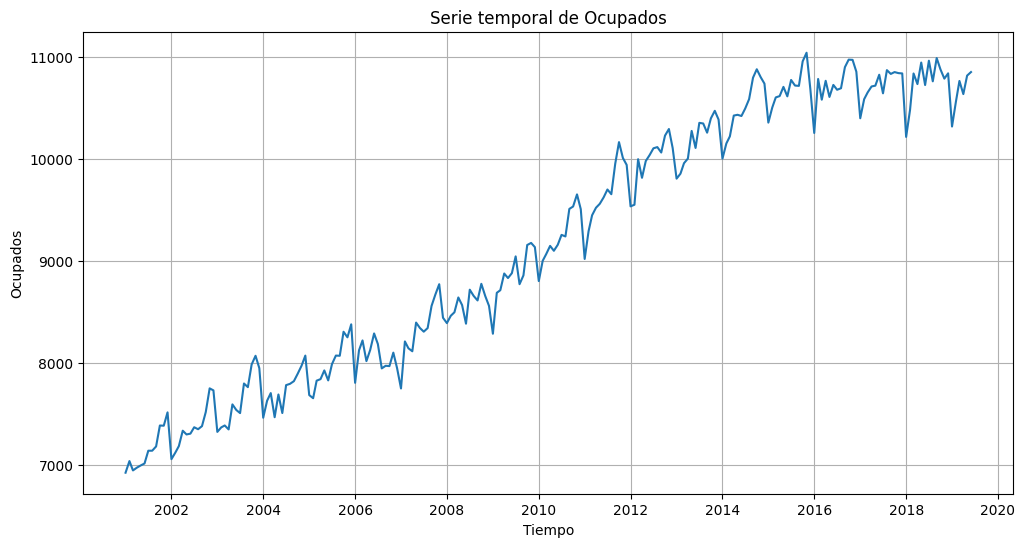

In [92]:
# imprimiendo el tamaño del dataframe
print(data.shape)

# graficando la serie temporal

fig = plt.figure(figsize=(12,6))

plt.title("Serie temporal de Ocupados")
plt.xlabel("Tiempo")
plt.ylabel("Ocupados")

plt.plot(data['Ocupados'])

plt.grid()

plt.show()

La serie temporal de ocupados presenta una tendencia creciente a lo largo del tiempo, así como fluctuaciones periódicas que podrían estar asociadas a componentes estacionales. Debido a este comportamiento, resulta pertinente evaluar modelos de regresión para series de tiempo que permitan capturar tanto la tendencia como la estacionalidad presente en los datos.

## **3. Autocorrelación**

Para determinar si existe autocorrelación en la serie de ocupados vamos a usar la prueba de rachas propuesta por Wald y Wolfowitz. Esta es una prueba no paramétrica donde las hipótesis son:

**H0:** ρ = 0, es decir, no hay autocorrelación.  
**H1:** ρ ≠ 0, es decir, hay autocorrelación.

Se rechaza H0 cuando el p-valor es menor al nivel de significancia, considerando α = 0.05.

In [93]:
# Se crea una variable lógica comparando la serie con su media
signo_ocupados = (data['Ocupados'] - data['Ocupados'].mean()) > 0

# Prueba de rachas
runstest_1samp(signo_ocupados, correction=False)

(np.float64(-14.260364883750725), np.float64(3.864287094208414e-46))

El segundo valor corresponde al p-valor de la prueba, el cual es significativamente menor a 0.05. Por lo tanto, se rechaza la hipótesis nula de no autocorrelación y se concluye que la serie de ocupados presenta autocorrelación temporal. Esto indica que los valores observados dependen de observaciones pasadas y que la serie no se comporta como ruido blanco.

Este análisis debe complementarse con otras pruebas como la prueba de Box-Pierce y la modificación de Ljung-Box para muestras pequeñas.

In [94]:
# prueba de Box-Pierce y la modificación de Ljung-Box

sm.stats.acorr_ljungbox(
    data['Ocupados'],
    lags=[1],
    return_df=True,
    boxpierce=True
)

,lb_stat,lb_pvalue,bp_stat,bp_pvalue
1,215.466151,8.818153e-49,212.580444,3.757527e-48


Los resultados de las pruebas de Box-Pierce y Ljung-Box muestran valores p significativamente menores a 0.05, por lo que se rechaza la hipótesis nula de no autocorrelación. Esto permite concluir que la serie de ocupados presenta dependencia temporal entre sus observaciones y no se comporta como ruido blanco.

In [95]:
# Evaluación de autocorrelación para los primeros 20 rezagos

Resul_lb_bp = sm.stats.acorr_ljungbox(
    data['Ocupados'],
    lags=range(1,21),
    return_df=True,
    boxpierce=True
)

# Decisión para Ljung-Box
Resul_lb_bp["lb_h0"] = np.where(
    Resul_lb_bp['lb_pvalue'] < 0.05,
    'rechazo_ho/hay_autocorr',
    'no_rechazo_ho/no_hay_autocorr'
)

# Decisión para Box-Pierce
Resul_lb_bp["bp_h0"] = np.where(
    Resul_lb_bp['bp_pvalue'] < 0.05,
    'rechazo_ho/hay_autocorr',
    'no_rechazo_ho/no_hay_autocorr'
)

Resul_lb_bp

,lb_stat,lb_pvalue,bp_stat,bp_pvalue,lb_h0,bp_h0
1,215.466151,8.818153e-49,212.580444,3.757527e-48,rechazo_ho/hay_autocorr,rechazo_ho/hay_autocorr
2,425.045838,5.040446e-93,418.417636,1.386005e-91,rechazo_ho/hay_autocorr,rechazo_ho/hay_autocorr
3,629.973395,3.201138e-136,618.770917,8.590288e-134,rechazo_ho/hay_autocorr,rechazo_ho/hay_autocorr
4,830.534686,1.866623e-178,813.960031,7.268819e-175,rechazo_ho/hay_autocorr,rechazo_ho/hay_autocorr
5,1028.006530,5.191558e-220,1005.260880,4.364213e-215,rechazo_ho/hay_autocorr,rechazo_ho/hay_autocorr
6,1222.035167,8.145806e-261,1192.359923,2.155332e-254,rechazo_ho/hay_autocorr,rechazo_ho/hay_autocorr
7,1412.841689,6.426069e-301,1375.500111,7.718370e-293,rechazo_ho/hay_autocorr,rechazo_ho/hay_autocorr
8,1599.512253,0.000000e+00,1553.837168,0.000000e+00,rechazo_ho/hay_autocorr,rechazo_ho/hay_autocorr
9,1782.749605,0.000000e+00,1728.076257,0.000000e+00,rechazo_ho/hay_autocorr,rechazo_ho/hay_autocorr
10,1963.258217,0.000000e+00,1898.914764,0.000000e+00,rechazo_ho/hay_autocorr,rechazo_ho/hay_autocorr


Los resultados obtenidos para los primeros 20 rezagos muestran que tanto la prueba de Ljung-Box como la prueba de Box-Pierce rechazan consistentemente la hipótesis nula de no autocorrelación. Esto indica que la serie de ocupados presenta una fuerte dependencia temporal entre observaciones y no se comporta como ruido blanco.

La presencia de autocorrelación sugiere que los valores pasados contienen información relevante para explicar el comportamiento futuro de la serie, justificando así el uso de modelos de series de tiempo que incorporen componentes de tendencia y estacionalidad.

## **4. Homoscedasticidad y Heteroscedasticidad**

Ahora se procederá a evaluar si la serie presenta problemas de heteroscedasticidad, especialmente un comportamiento tipo ARCH o GARCH, lo cual implicaría que la varianza de la serie no es constante a través del tiempo.

Una aproximación para determinar si existe un comportamiento ARCH o GARCH es aplicar la prueba de Ljung-Box sobre la serie al cuadrado.

**H0:** Comportamiento homoscedástico (varianza constante)

**H1:** Comportamiento heteroscedástico (varianza no constante)

In [96]:
ocupados2 = data['Ocupados']**2

Los resultados de las pruebas de Ljung-Box y Box-Pierce aplicadas sobre la serie al cuadrado presentan valores p menores a 0.05. Por lo tanto, se rechaza la hipótesis nula de homoscedasticidad y se concluye que la serie presenta heteroscedasticidad, es decir, la varianza no permanece constante a través del tiempo.

In [97]:
sm.stats.acorr_ljungbox(
    (data['Ocupados'] - data['Ocupados'].mean())**2,
    lags=range(1,21),
    return_df=True,
    boxpierce=True
)

,lb_stat,lb_pvalue,bp_stat,bp_pvalue
1,185.144285,3.650054e-42,182.664674,1.269512e-41
2,351.726827,4.202327e-77,346.272528,6.425041e-76
3,503.667333,7.654204e-109,494.821504,6.322880e-107
4,644.388355,3.822171e-138,631.773213,2.056334e-135
5,779.932738,2.537066e-166,763.081835,1.120126e-162
6,908.018395,6.939421e-193,886.593004,2.972305e-188
7,1033.010933,8.866253e-219,1006.563521,4.598527e-213
8,1150.214310,5.463849e-243,1118.534603,3.804834e-236
9,1265.945521,6.998913e-267,1228.582585,8.181347e-259
10,1382.954411,4.749866e-291,1339.323142,1.245900e-281


Los resultados de las pruebas de Ljung-Box y Box-Pierce aplicadas sobre la serie centrada al cuadrado presentan valores p significativamente menores a 0.05 para todos los rezagos evaluados. Por lo tanto, se rechaza la hipótesis nula de homoscedasticidad y se concluye que la serie presenta heteroscedasticidad, es decir, la varianza no permanece constante a través del tiempo.

Este comportamiento sugiere la posible presencia de patrones tipo ARCH o GARCH en la serie de ocupados, indicando que la volatilidad cambia entre distintos periodos de tiempo.

## **5. Normalidad**

Finalmente, podemos evaluar si la serie sigue una distribución normal o no. Es importante notar que esto no es un requisito para que la serie sea ruido blanco, sino específicamente para que se comporte como ruido blanco gaussiano.

Inicialmente se realiza un análisis gráfico mediante un QQ-Plot.

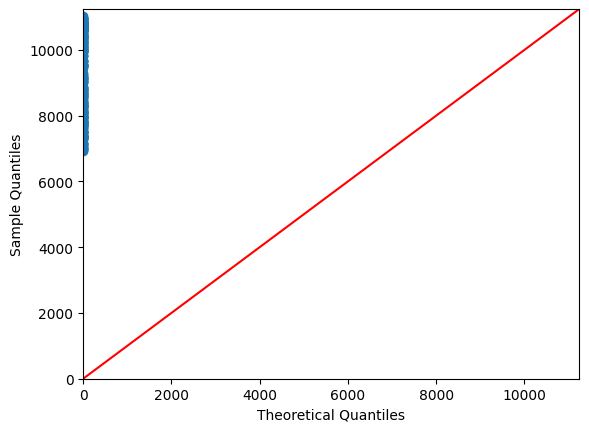

In [98]:
sm.qqplot(data['Ocupados'], line ='45')

py.show()

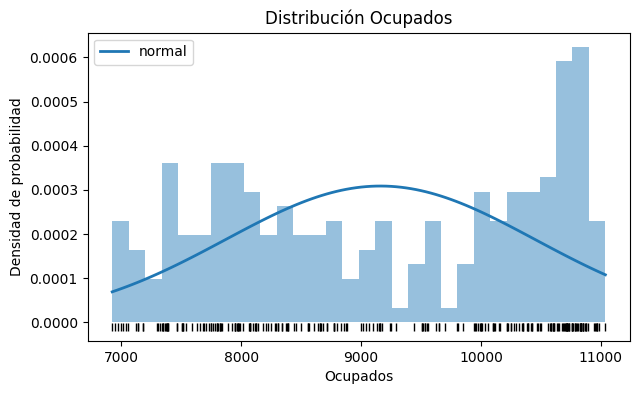

In [99]:
# Histograma + curva normal teórica

# Valores de la media (mu) y desviación típica (sigma)
mu, sigma = stats.norm.fit(data['Ocupados'])

# Valores teóricos de la normal en el rango observado
x_hat = np.linspace(min(data['Ocupados']),
                    max(data['Ocupados']),
                    num=100)

y_hat = stats.norm.pdf(x_hat, mu, sigma)

# Gráfico
fig, ax = plt.subplots(figsize=(7,4))

ax.plot(x_hat, y_hat, linewidth=2, label='normal')

ax.hist(data['Ocupados'],
        density=True,
        bins=30,
        color='#3182bd',
        alpha=0.5)

ax.plot(data['Ocupados'],
        np.full_like(data['Ocupados'], -0.00001),
        '|k',
        markeredgewidth=1)

ax.set_title('Distribución Ocupados')
ax.set_xlabel('Ocupados')
ax.set_ylabel('Densidad de probabilidad')

ax.legend()

In [100]:
# Prueba de Shapiro-Wilk
stats.shapiro(data['Ocupados'])

ShapiroResult(statistic=np.float64(0.9111439682568433), pvalue=np.float64(3.039085379954234e-10))

In [101]:
# Prueba de Jarque-Bera
stats.jarque_bera(data['Ocupados'])

SignificanceResult(statistic=np.float64(20.11813814008792), pvalue=np.float64(4.2795865091983345e-05))

El QQ-Plot evidencia desviaciones importantes respecto a la línea de referencia, especialmente en distintos sectores de la distribución, lo que sugiere que la serie no sigue un comportamiento normal. De igual forma, el histograma y la curva normal teórica muestran diferencias entre la distribución observada y una distribución normal ideal.

Adicionalmente, las pruebas de Shapiro-Wilk y Jarque-Bera presentan valores p menores a 0.05, por lo que se rechaza la hipótesis nula de normalidad. En consecuencia, se concluye que la serie de ocupados no sigue una distribución normal.

## **6. Tendencia Lineal**


In [102]:
#Definición de variables
y = data['Ocupados']

x = np.linspace(1, data.shape[0], data.shape[0])

X = sm.add_constant(x)

In [103]:
#Ajuste del modelo
lin_t = sm.OLS(y, X)

lin_t = lin_t.fit()

print(lin_t.summary())

                            OLS Regression Results                            
Dep. Variable:               Ocupados   R-squared:                       0.956
Model:                            OLS   Adj. R-squared:                  0.955
Method:                 Least Squares   F-statistic:                     4729.
Date:                Mon, 08 Jun 2026   Prob (F-statistic):          1.02e-150
Time:                        07:43:06   Log-Likelihood:                -1559.9
No. Observations:                 222   AIC:                             3124.
Df Residuals:                     220   BIC:                             3131.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       6962.4958     36.871    188.835      0.0

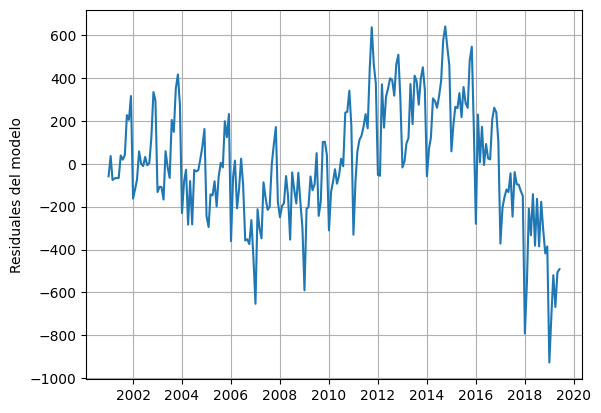

In [104]:
plt.ylabel('Residuales del modelo')

plt.plot(lin_t.resid)

plt.grid()

Aunque el modelo lineal logra capturar la tendencia general de la serie, los residuales muestran ciertos patrones y cambios en distintos periodos de tiempo, por lo que no parecen completamente aleatorios. Esto sugiere que podrían existir componentes adicionales, como curvaturas o efectos estacionales, que no están siendo explicados completamente por el modelo lineal.

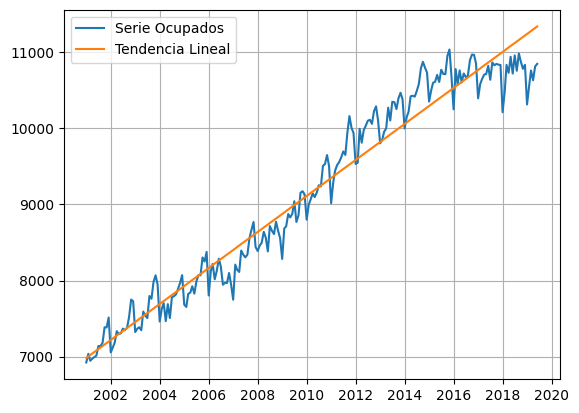

In [105]:
#Gráfica ajuste lineal
plt.plot(y, label='Serie Ocupados')

plt.plot(lin_t.fittedvalues,
         label='Tendencia Lineal')

plt.legend()

plt.grid()

plt.show()

La tendencia lineal logra representar adecuadamente el crecimiento general de la serie de ocupados a lo largo del tiempo. Sin embargo, se observan diferencias entre la serie real y la línea ajustada en algunos periodos, especialmente hacia el final de la muestra, lo que sugiere la presencia de comportamientos no lineales y posibles efectos estacionales que no son capturados completamente por el modelo lineal.

In [106]:
#Pronóstico

h = 6

x_for = np.linspace((data.shape[0]+1),
                    (data.shape[0]+h),
                    h)

X_for = sm.add_constant(x_for)

In [107]:
#Predicciones e intervalos
dt = lin_t.get_prediction(X_for).summary_frame(alpha = 0.05)

y_prd = dt['mean']

yprd_ci_lower = dt['obs_ci_lower']

yprd_ci_upper = dt['obs_ci_upper']

preds = pd.DataFrame(
    np.column_stack([y_prd,
                     yprd_ci_lower,
                     yprd_ci_upper])
)

preds.columns = ['Point_forecast',
                 'lower_95',
                 'upper_95']

print(preds)

   Point_forecast      lower_95      upper_95
0    11359.208189  10814.820716  11903.595662
1    11378.924388  10834.471236  11923.377539
2    11398.640587  10854.121178  11943.159995
3    11418.356786  10873.770542  11962.943029
4    11438.072984  10893.419328  11982.726641
5    11457.789183  10913.067536  12002.510831


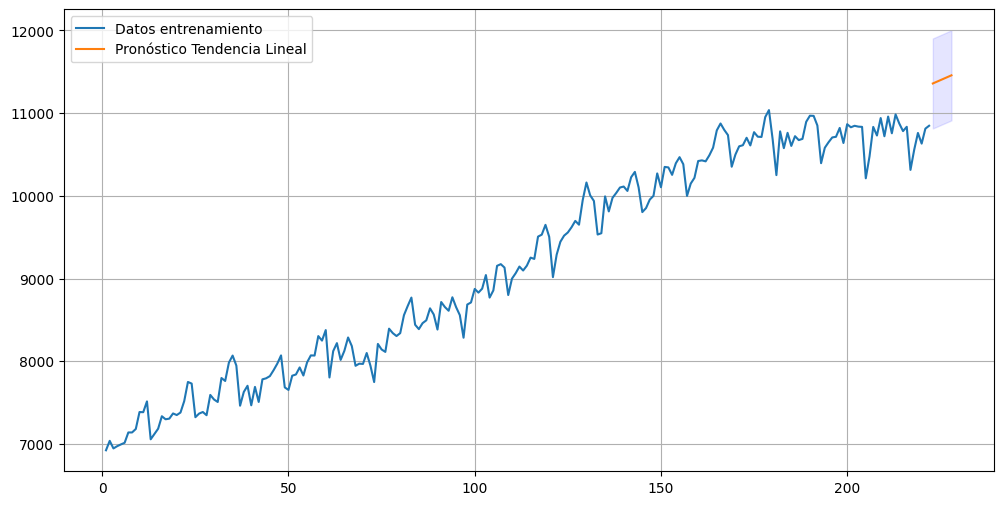

In [108]:
fig = plt.figure(figsize=(12, 6))

plt.plot(x, y,
         label="Datos entrenamiento")

plt.plot(x_for,
         preds['Point_forecast'],
         label="Pronóstico Tendencia Lineal")

plt.fill_between(x_for,
                 preds['lower_95'],
                 preds['upper_95'],
                 color='blue',
                 alpha=0.1)

plt.legend()

plt.grid()

plt.show()

El modelo de tendencia lineal proyecta un crecimiento sostenido del número de ocupados durante los próximos seis meses. Los intervalos de confianza muestran el rango esperado de variación de las predicciones y reflejan la incertidumbre asociada al pronóstico.

Sin embargo, al comparar el ajuste lineal con la serie observada, se evidencia que el comportamiento real no sigue completamente una trayectoria recta, especialmente en los periodos finales de la muestra. Esto sugiere que podrían existir componentes no lineales que serían mejor capturados mediante modelos más complejos.

## **7. Tendencia Cuadratica**

In [109]:
y = data["Ocupados"]

data["x"] = np.linspace(1, data.shape[0], data.shape[0])

data["x2"] = data["x"]**2

X = sm.add_constant(data[["x","x2"]])

pol_2 = sm.OLS(y, X)

pol_2 = pol_2.fit()

print(pol_2.summary())

                            OLS Regression Results                            
Dep. Variable:               Ocupados   R-squared:                       0.959
Model:                            OLS   Adj. R-squared:                  0.959
Method:                 Least Squares   F-statistic:                     2560.
Date:                Mon, 08 Jun 2026   Prob (F-statistic):          1.33e-152
Time:                        07:43:06   Log-Likelihood:                -1551.0
No. Observations:                 222   AIC:                             3108.
Df Residuals:                     219   BIC:                             3118.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       6790.8804     53.552    126.810      0.0

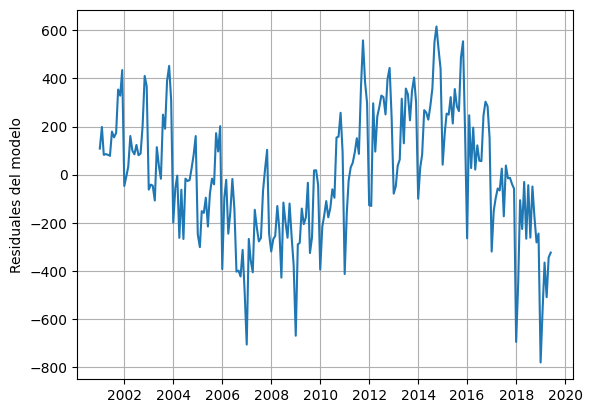

In [110]:
plt.ylabel('Residuales del modelo')

plt.plot(pol_2.resid)

plt.grid()

El modelo de tendencia cuadrática presenta un mejor ajuste que el modelo lineal, alcanzando un R² de 0.959. Tanto la variable de tendencia lineal como el término cuadrático resultan estadísticamente significativos (p-value < 0.05), lo que confirma que la serie presenta un comportamiento no completamente lineal.

El coeficiente negativo asociado al término cuadrático indica que, aunque la serie continúa mostrando una tendencia creciente, el crecimiento comienza a desacelerarse ligeramente en los periodos más recientes. Esto puede observarse también en los residuales del modelo, los cuales presentan una ligera mejora respecto al modelo lineal y muestran una mayor concentración alrededor de cero.

Sin embargo, todavía se identifican ciertos patrones y variaciones sistemáticas en distintos periodos de tiempo, por lo que los residuales no parecen completamente aleatorios. Esto sugiere que, aunque la tendencia cuadrática captura mejor el comportamiento de la serie, aún podrían existir componentes estacionales u otras estructuras no explicadas completamente por el modelo.


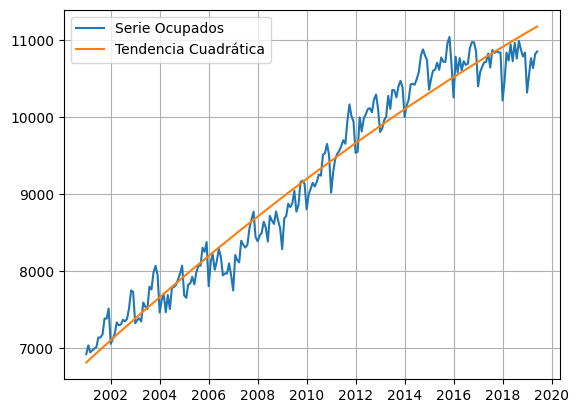

In [111]:
plt.plot(y, label='Serie Ocupados')

plt.plot(pol_2.fittedvalues,
         label='Tendencia Cuadrática')

plt.legend()

plt.grid()

plt.show()

La gráfica del modelo cuadrático muestra un mejor ajuste respecto al modelo lineal, especialmente en los periodos más recientes de la serie. La tendencia cuadrática logra seguir de manera más adecuada la curvatura observada en el comportamiento de los ocupados, representando de mejor forma la desaceleración del crecimiento hacia el final del periodo analizado.

Aunque todavía existen diferencias entre la serie observada y los valores ajustados, el modelo cuadrático captura con mayor precisión la dinámica general de la serie temporal.


In [112]:
# Pronóstico

h = 6

x_for = np.linspace((data.shape[0]+1),
                    (data.shape[0]+h),
                    h)

X_for = sm.add_constant(
    np.stack((x_for, x_for**2), axis=1)
)

In [113]:
#Predicciones e intervalos
dt = pol_2.get_prediction(X_for).summary_frame(alpha = 0.05)

y_prd = dt['mean']

yprd_ci_lower = dt['obs_ci_lower']

yprd_ci_upper = dt['obs_ci_upper']

preds = pd.DataFrame(
    np.column_stack([y_prd,
                     yprd_ci_lower,
                     yprd_ci_upper])
)

preds.columns = ['Point_forecast',
                 'lower_95',
                 'upper_95']

print(preds)

   Point_forecast      lower_95      upper_95
0    11187.592748  10657.511767  11717.673730
1    11202.691491  10672.226911  11733.156072
2    11217.749007  10686.889054  11748.608961
3    11232.765296  10701.497992  11764.032599
4    11247.740357  10716.053522  11779.427192
5    11262.674191  10730.555438  11794.792944


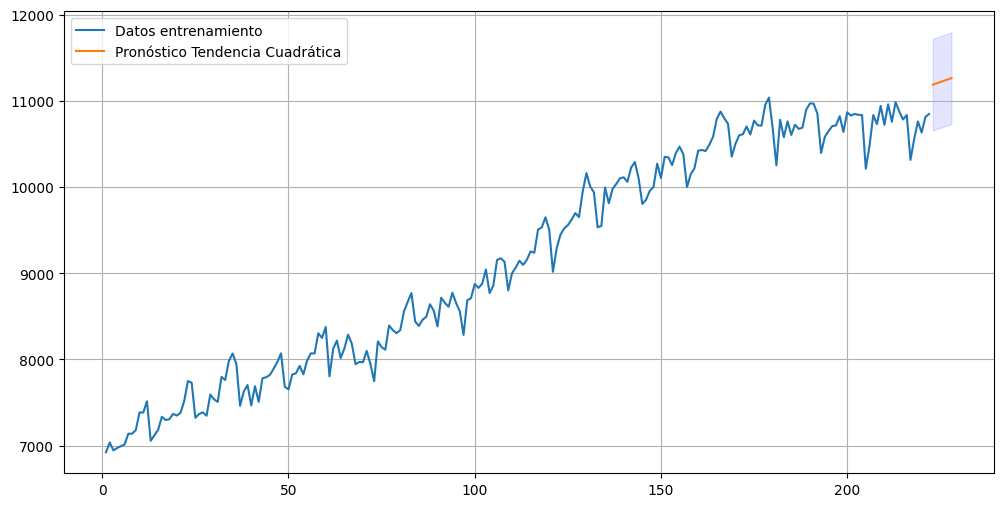

In [114]:
fig = plt.figure(figsize=(12, 6))

plt.plot(x, y,
         label="Datos entrenamiento")

plt.plot(x_for,
         preds['Point_forecast'],
         label="Pronóstico Tendencia Cuadrática")

plt.fill_between(x_for,
                 preds['lower_95'],
                 preds['upper_95'],
                 color='blue',
                 alpha=0.1)

plt.legend()

plt.grid()

plt.show()

El modelo de tendencia cuadrática proyecta un crecimiento moderado del número de ocupados durante los próximos seis meses. A diferencia del modelo lineal, este modelo incorpora una curvatura en la tendencia, permitiendo representar de mejor manera el comportamiento reciente de la serie.

Los pronósticos estimados oscilan aproximadamente entre 11,187 y 11,262 ocupados, mostrando un incremento gradual en los periodos futuros. Asimismo, los intervalos de confianza reflejan la incertidumbre asociada a las predicciones y muestran un rango razonable de variación alrededor de los valores pronosticados.

La gráfica evidencia que la tendencia cuadrática logra ajustarse mejor a la forma observada de la serie, especialmente en los periodos finales, donde el crecimiento comienza a desacelerarse ligeramente. Esto representa una mejora frente al modelo lineal, aunque todavía pueden existir componentes estacionales no capturados completamente por el modelo.


## **8. Estimación de la Estacionalidad**

In [115]:
month_dummies = pd.get_dummies(
    data.index.month,
    drop_first=True,
    dtype=float
).set_index(data.index)

y = data["Ocupados"]

X = sm.add_constant(month_dummies)

sea = sm.OLS(y, X)

season = sea.fit()

print(season.summary())

                            OLS Regression Results                            
Dep. Variable:               Ocupados   R-squared:                       0.014
Model:                            OLS   Adj. R-squared:                 -0.038
Method:                 Least Squares   F-statistic:                    0.2687
Date:                Mon, 08 Jun 2026   Prob (F-statistic):              0.991
Time:                        07:43:07   Log-Likelihood:                -1903.9
No. Observations:                 222   AIC:                             3832.
Df Residuals:                     210   BIC:                             3873.
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       8808.2176    302.768     29.092      0.0

El modelo basado únicamente en componentes estacionales presenta un bajo nivel explicativo para la serie de ocupados, alcanzando un R² de apenas 0.014. Adicionalmente, la mayoría de las variables dummy asociadas a los meses no resultan estadísticamente significativas, ya que sus valores p son mayores a 0.05.

Estos resultados sugieren que la estacionalidad por sí sola no logra explicar adecuadamente el comportamiento de la serie temporal. Esto indica que la dinámica de la serie está principalmente asociada a la tendencia creciente observada a lo largo del tiempo, mientras que los efectos estacionales parecen tener una influencia mucho menor.


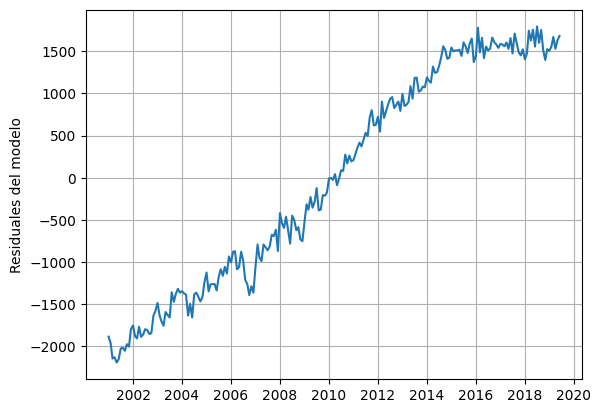

In [116]:
plt.ylabel("Residuales del modelo")

plt.plot(season.resid)

plt.grid()

Los residuales del modelo estacional presentan un patrón claramente creciente y no se comportan de manera aleatoria alrededor de cero. Esto evidencia que el modelo basado únicamente en estacionalidad no logra capturar adecuadamente la tendencia presente en la serie de ocupados.

La estructura observada en los residuales confirma que la tendencia es el componente predominante de la serie temporal, mientras que la estacionalidad por sí sola resulta insuficiente para explicar el comportamiento de los datos.


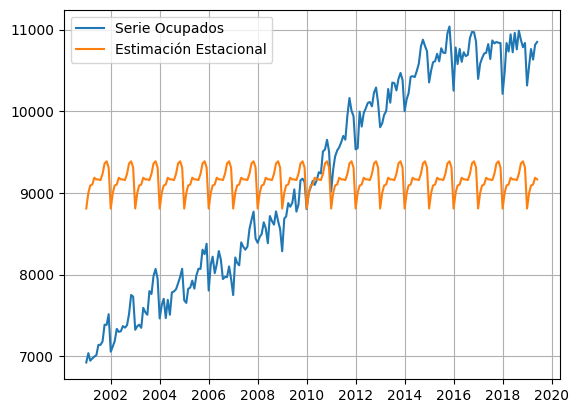

In [117]:
#Ajuste del modelo
plt.plot(y, label="Serie Ocupados")

plt.plot(season.fittedvalues,
         label="Estimación Estacional")

plt.legend()

plt.grid()

plt.show()

La gráfica del modelo estacional evidencia que la estimación captura pequeñas variaciones periódicas asociadas a los meses del año; sin embargo, no logra representar la tendencia creciente observada en la serie de ocupados.

La estimación permanece relativamente estable alrededor de un nivel promedio, mientras que la serie real presenta un crecimiento sostenido a lo largo del tiempo. Esto confirma que la estacionalidad por sí sola no es suficiente para modelar adecuadamente la dinámica de la serie temporal y que resulta necesario incorporar componentes de tendencia en el modelo.


In [118]:
range_dates = pd.date_range(
    data.index[-1] + relativedelta(months=1),
    periods=6,
    freq='MS'
)

x_for = pd.get_dummies(
    range_dates.month,
    drop_first=True,
    dtype=float
)

X_for = sm.add_constant(x_for)

In [119]:
# Fechas futuras: 6 meses
range_dates = pd.date_range(
    data.index[-1] + relativedelta(months=1),
    periods=6,
    freq='MS'
)

# Crear dummies para meses futuros
x_for = pd.get_dummies(
    range_dates.month,
    drop_first=True,
    dtype=float
)

# Asegurar que tenga las mismas columnas que el modelo original
x_for = x_for.reindex(columns=month_dummies.columns, fill_value=0)

# Agregar constante
X_for = sm.add_constant(x_for, has_constant='add')

# Predicciones e intervalos
dt = season.get_prediction(X_for).summary_frame(alpha=0.05)

y_prd = dt['mean']
yprd_ci_lower = dt['obs_ci_lower']
yprd_ci_upper = dt['obs_ci_upper']

preds = pd.DataFrame(
    np.column_stack([y_prd, yprd_ci_lower, yprd_ci_upper]),
    index=range_dates,
    columns=['Point_forecast', 'lower_95', 'upper_95']
)

print(preds)

            Point_forecast     lower_95      upper_95
2019-07-01     8808.217632  6139.005354  11477.429909
2019-08-01     9156.633500  6483.716554  11829.550446
2019-09-01     9232.988500  6560.071554  11905.905446
2019-10-01     9359.934944  6687.017999  12032.851890
2019-11-01     9386.702222  6713.785277  12059.619168
2019-12-01     9310.332667  6637.415721  11983.249612


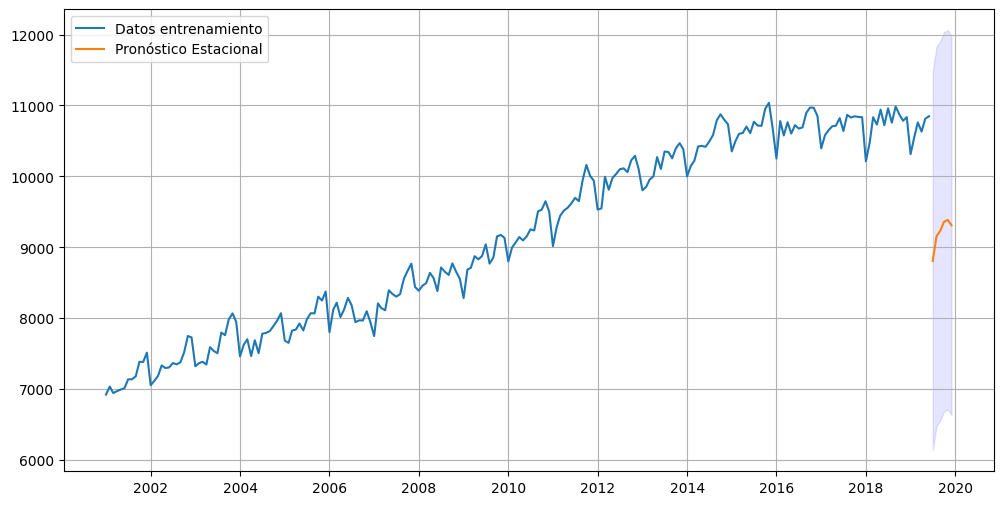

In [120]:
fig = plt.figure(figsize=(12, 6))

plt.plot(
    y.index,
    y,
    label="Datos entrenamiento"
)

plt.plot(
    preds.index,
    preds['Point_forecast'],
    label="Pronóstico Estacional"
)

plt.fill_between(
    preds.index,
    preds['lower_95'],
    preds['upper_95'],
    color='blue',
    alpha=0.1
)

plt.legend()

plt.grid()

plt.show()

El modelo estacional genera pronósticos relativamente estables para los próximos seis meses, con valores cercanos a los 9,000 ocupados. Sin embargo, tanto la gráfica como los intervalos de confianza evidencian que este modelo no logra representar adecuadamente el comportamiento real de la serie temporal.

La estimación estacional únicamente captura fluctuaciones periódicas entre meses, pero no incorpora la fuerte tendencia creciente observada en la serie histórica. Como consecuencia, los pronósticos obtenidos se mantienen considerablemente por debajo de los valores recientes observados.

Además, los intervalos de confianza son bastante amplios, reflejando una alta incertidumbre en las predicciones. Esto confirma que la estacionalidad por sí sola no es suficiente para modelar correctamente la dinámica de la serie de ocupados y que resulta necesario incorporar componentes de tendencia dentro del modelo.


## **9. Tendencia + Estacionalidad**

In [121]:
y = data["Ocupados"]

data["x"] = np.linspace(1, data.shape[0], data.shape[0])
data["x2"] = data["x"]**2

month_dummies = pd.get_dummies(
    data.index.month,
    drop_first=True,
    dtype=float
).set_index(data.index)

X = sm.add_constant(
    pd.concat([data[["x", "x2"]], month_dummies], axis=1)
)

season_pol_2 = sm.OLS(y, X)

season_pol_2 = season_pol_2.fit()

print(season_pol_2.summary())

                            OLS Regression Results                            
Dep. Variable:               Ocupados   R-squared:                       0.969
Model:                            OLS   Adj. R-squared:                  0.967
Method:                 Least Squares   F-statistic:                     502.6
Date:                Mon, 08 Jun 2026   Prob (F-statistic):          3.33e-149
Time:                        07:43:08   Log-Likelihood:                -1519.4
No. Observations:                 222   AIC:                             3067.
Df Residuals:                     208   BIC:                             3114.
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       6508.3401     69.460     93.700      0.0

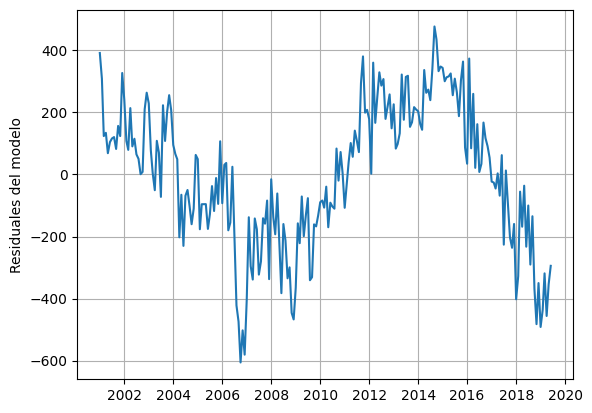

In [122]:
plt.ylabel("Residuales del modelo")

plt.plot(season_pol_2.resid)

plt.grid()

El modelo combinado de tendencia y estacionalidad presenta el mejor ajuste entre todos los modelos evaluados, alcanzando un R² de 0.969, lo que indica que logra explicar aproximadamente el 96.9% de la variabilidad de la serie de ocupados. Tanto las variables de tendencia como la mayoría de las variables estacionales resultan estadísticamente significativas, evidenciando que el comportamiento de la serie depende tanto del crecimiento temporal como de ciertos patrones estacionales.

Adicionalmente, el término cuadrático mantiene un coeficiente negativo y significativo, confirmando una ligera desaceleración del crecimiento en los periodos más recientes. Los residuales del modelo muestran una mejora importante respecto a los modelos anteriores, observándose una mayor concentración alrededor de cero y una reducción en la magnitud de las fluctuaciones. Aunque todavía existen algunos patrones residuales, el modelo logra capturar de manera más adecuada la dinámica general de la serie temporal.


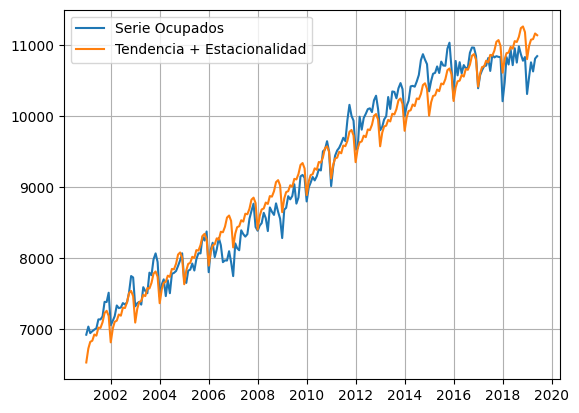

In [123]:
#Ajuste del modelo
plt.plot(y,
         label="Serie Ocupados")

plt.plot(
    season_pol_2.fittedvalues,
    label="Tendencia + Estacionalidad"
)

plt.legend()

plt.grid()

plt.show()

La gráfica del modelo combinado de tendencia y estacionalidad evidencia un ajuste considerablemente mejor respecto a los modelos evaluados anteriormente. La estimación logra seguir de manera más cercana el comportamiento de la serie real, capturando tanto la tendencia creciente como las fluctuaciones estacionales presentes en distintos periodos.

A diferencia de los modelos individuales, este enfoque permite representar de forma más completa la dinámica de la serie temporal, mostrando una trayectoria ajustada mucho más próxima a los valores observados. Esto confirma que la combinación de componentes de tendencia y estacionalidad proporciona una representación más adecuada del comportamiento de la serie de ocupados.


In [124]:
#Pronóstico
h = 6

x_for = np.linspace(
    (data.shape[0]+1),
    (data.shape[0]+h),
    h
)

X_for_all = pd.DataFrame(
    np.stack((x_for, x_for**2), axis=1),
    columns=["x", "x2"]
)

range_dates = pd.date_range(
    data.index[-1] + relativedelta(months=1),
    periods=h,
    freq='MS'
)

x_for_dummies = pd.get_dummies(
    range_dates.month,
    drop_first=True,
    dtype=float
)

# Ajustar columnas para que coincidan
x_for_dummies = x_for_dummies.reindex(
    columns=month_dummies.columns,
    fill_value=0
)

X_for = sm.add_constant(
    pd.concat([X_for_all, x_for_dummies], axis=1),
    has_constant='add'
)

X_for

,const,x,x2,2,3,4,5,6,7,8,9,10,11,12
0,1.0,223.0,49729.0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0
1,1.0,224.0,50176.0,0,0,0,0,0,0,1.0,0.0,0.0,0.0,0.0
2,1.0,225.0,50625.0,0,0,0,0,0,0,0.0,1.0,0.0,0.0,0.0
3,1.0,226.0,51076.0,0,0,0,0,0,0,0.0,0.0,1.0,0.0,0.0
4,1.0,227.0,51529.0,0,0,0,0,0,0,0.0,0.0,0.0,1.0,0.0
5,1.0,228.0,51984.0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,1.0


In [125]:
#Predicciones e intervalos
dt = season_pol_2.get_prediction(X_for).summary_frame(alpha = 0.05)

y_prd = dt['mean']

yprd_ci_lower = dt['obs_ci_lower']

yprd_ci_upper = dt['obs_ci_upper']

preds = pd.DataFrame(
    np.column_stack([y_prd,
                     yprd_ci_lower,
                     yprd_ci_upper])
)

preds.columns = ['Point_forecast',
                 'lower_95',
                 'upper_95']

preds.set_index(range_dates, inplace=True)

print(preds)

            Point_forecast      lower_95      upper_95
2019-07-01    10899.308298  10416.761632  11381.854965
2019-08-01    11234.988869  10750.954256  11719.023481
2019-09-01    11307.022964  10822.688332  11791.357595
2019-10-01    11429.648504  10945.006353  11914.290654
2019-11-01    11452.094877  10967.137722  11937.052032
2019-12-01    11371.404416  10886.124786  11856.684047


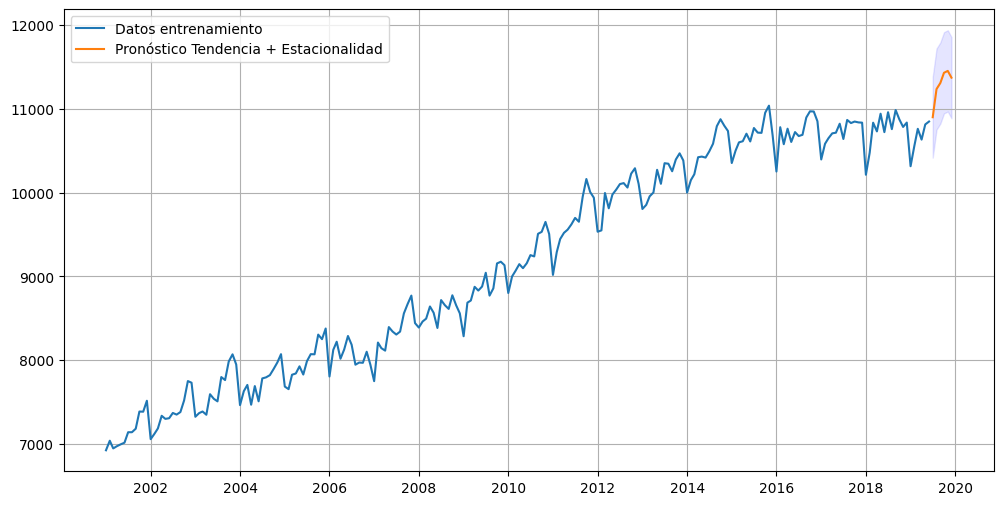

In [126]:
fig = plt.figure(figsize=(12, 6))

plt.plot(
    y.index,
    y,
    label="Datos entrenamiento"
)

plt.plot(
    preds.index,
    preds['Point_forecast'],
    label="Pronóstico Tendencia + Estacionalidad"
)

plt.fill_between(
    preds.index,
    preds['lower_95'],
    preds['upper_95'],
    color='blue',
    alpha=0.1
)

plt.legend()

plt.grid()

plt.show()

El modelo combinado de tendencia y estacionalidad genera los pronósticos más consistentes y realistas entre todos los modelos evaluados. Los valores pronosticados para los próximos seis meses oscilan aproximadamente entre 10,899 y 11,371 ocupados, manteniendo la tendencia creciente observada en los periodos más recientes de la serie.

La gráfica evidencia que este modelo logra ajustarse de manera mucho más cercana al comportamiento real de los datos, capturando tanto el crecimiento de largo plazo como las fluctuaciones estacionales presentes en distintos momentos del tiempo. Además, los intervalos de confianza muestran un rango razonable de variación alrededor de las predicciones, reflejando la incertidumbre inherente a cualquier pronóstico.

En comparación con los modelos anteriores, el modelo de tendencia más estacionalidad presenta el mejor desempeño general, tanto en términos estadísticos como visuales, por lo que puede considerarse el modelo más adecuado para realizar las proyecciones futuras de la serie de ocupados.


## **10. Comparación de modelos**

Para comparar el desempeño de los modelos se utilizará una evaluación fuera de muestra empleando el RMSE como métrica principal. Para ello, la serie se divide en un conjunto de entrenamiento y un conjunto de prueba, permitiendo evaluar la capacidad predictiva de cada modelo sobre datos no utilizados en el ajuste.

In [127]:
train = data.iloc[:-6]

test = data.iloc[-6:]

print(train.shape)

print(test.shape)

(216, 6)
(6, 6)


### Modelo Lineal

In [128]:
# Variables entrenamiento
y_train = train["Ocupados"]

x_train = np.linspace(1, train.shape[0], train.shape[0])

X_train = sm.add_constant(x_train)

# Modelo lineal
model_lin = sm.OLS(y_train, X_train).fit()

# Horizonte test
x_test = np.linspace(
    train.shape[0] + 1,
    train.shape[0] + len(test),
    len(test)
)

X_test = sm.add_constant(x_test)

# Pronóstico
pred_lin = model_lin.predict(X_test)

pred_lin

array([11313.11634147, 11333.33524157, 11353.55414167, 11373.77304177,
       11393.99194188, 11414.21084198])

In [129]:
rmse_lin = np.sqrt(mean_squared_error(test["Ocupados"], pred_lin))

print("RMSE Tendencia Lineal:", rmse_lin)

RMSE Tendencia Lineal: 725.5285275153046


### Modelo Cuadrático

In [130]:
train = data.iloc[:-6].copy()
test = data.iloc[-6:].copy()

In [131]:
# Variables entrenamiento
train["x"] = np.linspace(1, train.shape[0], train.shape[0])

train["x2"] = train["x"]**2

X_train_quad = sm.add_constant(train[["x", "x2"]])

# Modelo cuadrático
model_quad = sm.OLS(
    train["Ocupados"],
    X_train_quad
).fit()

# Datos futuros para test
x_test = np.linspace(
    train.shape[0] + 1,
    train.shape[0] + len(test),
    len(test)
)

X_test_quad = pd.DataFrame({
    "x": x_test,
    "x2": x_test**2
})

X_test_quad = sm.add_constant(X_test_quad)

# Pronóstico
pred_quad = model_quad.predict(X_test_quad)

# RMSE
rmse_quad = np.sqrt(
    mean_squared_error(test["Ocupados"], pred_quad)
)

print("RMSE Tendencia Cuadrática:", rmse_quad)

RMSE Tendencia Cuadrática: 632.4766573075495


### Tendencia + Estacionalidad

In [132]:
# Crear dummies mensuales para train
month_dummies_train = pd.get_dummies(
    train.index.month,
    drop_first=True,
    dtype=float
).set_index(train.index)

# Variables tendencia
train["x"] = np.linspace(1, train.shape[0], train.shape[0])
train["x2"] = train["x"]**2

# Variables explicativas
X_train_full = sm.add_constant(
    pd.concat(
        [train[["x", "x2"]], month_dummies_train],
        axis=1
    )
)

# Ajustar modelo
model_full = sm.OLS(
    train["Ocupados"],
    X_train_full
).fit()

# Datos futuros para test
x_test = np.linspace(
    train.shape[0] + 1,
    train.shape[0] + len(test),
    len(test)
)

X_test_all = pd.DataFrame({
    "x": x_test,
    "x2": x_test**2
})

# Dummies futuras
month_dummies_test = pd.get_dummies(
    test.index.month,
    drop_first=True,
    dtype=float
)

# Alinear columnas
month_dummies_test = month_dummies_test.reindex(
    columns=month_dummies_train.columns,
    fill_value=0
)

# Construir matriz final
X_test_full = sm.add_constant(
    pd.concat(
        [X_test_all.reset_index(drop=True),
         month_dummies_test.reset_index(drop=True)],
        axis=1
    ),
    has_constant='add'
)

# Pronóstico
pred_full = model_full.predict(X_test_full)

# RMSE
rmse_full = np.sqrt(
    mean_squared_error(test["Ocupados"], pred_full)
)

print("RMSE Tendencia + Estacionalidad:", rmse_full)

RMSE Tendencia + Estacionalidad: 519.2259398377271


| Modelo                     |   RMSE |
| -------------------------- | -----: |
| Tendencia lineal           | 725.53 |
| Tendencia cuadrática       | 632.48 |
| Tendencia + Estacionalidad | 519.23 |


La comparación de modelos mediante el RMSE fuera de muestra evidencia que el modelo combinado de tendencia y estacionalidad presenta el mejor desempeño predictivo. El modelo lineal obtuvo un RMSE de 725.53, mientras que el modelo cuadrático redujo el error a 632.48. Finalmente, el modelo de tendencia más estacionalidad alcanzó el menor RMSE con un valor de 519.23.

Estos resultados indican que incorporar simultáneamente componentes de tendencia y estacionalidad permite representar de forma más adecuada la dinámica de la serie temporal y mejorar significativamente la capacidad de pronóstico.

Entre los modelos de regresión evaluados en esta actividad, el modelo de tendencia+estacionalidad presentó el mejor desempeño. Sin embargo, al compararlo con el ejercicio anterior, el modelo Holt-Winters multiplicativo continúa siendo el de menor RMSE.


In [139]:
comparacion = pd.DataFrame({
    "Modelo": [
        "Tendencia Lineal",
        "Tendencia Cuadrática",
        "Tendencia + Estacionalidad",
        "Holt-Winters Multiplicativo"
    ],
    "RMSE": [
        round(rmse_lin,2),
        round(rmse_quad,2),
        round(rmse_full,2),
        59.63
    ]
})

comparacion

,Modelo,RMSE
0,Tendencia Lineal,725.53
1,Tendencia Cuadrática,632.48
2,Tendencia + Estacionalidad,519.23
3,Holt-Winters Multiplicativo,59.63


La comparación de modelos evidencia que el modelo de tendencia más estacionalidad presentó el mejor desempeño entre los modelos de regresión evaluados en esta actividad, obteniendo el menor RMSE fuera de muestra. Sin embargo, al comparar estos resultados con el ejercicio anterior, se observa que el modelo Holt-Winters multiplicativo continúa siendo el modelo con mejor capacidad predictiva, alcanzando un RMSE considerablemente menor.


## **11. Evaluación de los supuestos de los residuales**

### 11.1 Autocorrelación en residuales


In [133]:
Resul_lb_bp = sm.stats.acorr_ljungbox(
    season_pol_2.resid,
    lags=range(1,21),
    return_df=True,
    boxpierce=True
)

Resul_lb_bp["lb_h0"] = np.where(
    Resul_lb_bp['lb_pvalue'] < 0.05,
    'rechazo_ho/hay_autocorr',
    'no_rechazo_ho/no_hay_autocorr'
)

Resul_lb_bp["bp_h0"] = np.where(
    Resul_lb_bp['bp_pvalue'] < 0.05,
    'rechazo_ho/hay_autocorr',
    'no_rechazo_ho/no_hay_autocorr'
)

Resul_lb_bp

,lb_stat,lb_pvalue,bp_stat,bp_pvalue,lb_h0,bp_h0
1,156.535880,6.464982e-36,154.439417,1.856521e-35,rechazo_ho/hay_autocorr,rechazo_ho/hay_autocorr
2,299.625352,8.653294e-66,294.973720,8.856671e-65,rechazo_ho/hay_autocorr,rechazo_ho/hay_autocorr
3,432.084767,2.481482e-93,424.476452,1.104069e-91,rechazo_ho/hay_autocorr,rechazo_ho/hay_autocorr
4,546.974803,4.617991e-117,536.289076,9.468743e-115,rechazo_ho/hay_autocorr,rechazo_ho/hay_autocorr
5,650.298901,2.728212e-138,636.384296,2.775553e-135,rechazo_ho/hay_autocorr,rechazo_ho/hay_autocorr
6,747.044127,4.239912e-158,729.674335,2.392105e-154,rechazo_ho/hay_autocorr,rechazo_ho/hay_autocorr
7,835.978106,3.188569e-176,815.035075,1.056423e-171,rechazo_ho/hay_autocorr,rechazo_ho/hay_autocorr
8,917.699737,8.584940e-193,893.108418,1.731264e-187,rechazo_ho/hay_autocorr,rechazo_ho/hay_autocorr
9,999.695796,2.005164e-209,971.077885,2.967508e-203,rechazo_ho/hay_autocorr,rechazo_ho/hay_autocorr
10,1075.458056,1.029271e-224,1042.781452,1.134136e-217,rechazo_ho/hay_autocorr,rechazo_ho/hay_autocorr


Las pruebas de Ljung-Box y Box-Pierce aplicadas sobre los residuales del modelo de tendencia más estacionalidad muestran valores p menores a 0.05 en todos los rezagos evaluados. Por lo tanto, se rechaza la hipótesis nula de no autocorrelación.

Estos resultados indican que los residuales todavía presentan dependencia temporal y no se comportan completamente como ruido blanco. Esto sugiere que, aunque el modelo logra capturar gran parte de la dinámica de la serie, aún existen patrones temporales no explicados completamente.


### 11.2 Homoscedasticidad / Heteroscedasticidad

In [134]:
sm.stats.acorr_ljungbox(
    (season_pol_2.resid - season_pol_2.resid.mean())**2,
    lags=range(1,21),
    return_df=True,
    boxpierce=True
)

,lb_stat,lb_pvalue,bp_stat,bp_pvalue
1,90.693598,1.677351e-21,89.478952,3.099183e-21
2,143.989903,5.407416e-32,141.823537,1.597387e-31
3,182.362076,2.724883e-39,179.339188,1.225094e-38
4,195.780344,3.033832e-41,192.398038,1.617926e-40
5,202.564285,8.031625e-42,198.969981,4.717905e-41
6,205.999208,1.002107e-41,202.282228,6.199906e-41
7,206.814217,4.132256e-41,203.064492,2.574889e-40
8,207.504525,1.672720e-40,203.723982,1.048665e-39
9,208.380966,5.782222e-40,204.557384,3.668611e-39
10,208.613909,2.569923e-39,204.777847,1.625501e-38


Las pruebas de Ljung-Box y Box-Pierce aplicadas sobre los residuales al cuadrado presentan valores p menores a 0.05 para todos los rezagos evaluados. Por lo tanto, se rechaza la hipótesis nula de homoscedasticidad.

Estos resultados sugieren la presencia de heteroscedasticidad en los residuales del modelo, indicando que la varianza de los errores no permanece constante a lo largo del tiempo. Esto puede asociarse a la existencia de patrones de volatilidad o comportamientos tipo ARCH/GARCH dentro de la serie temporal.


### 11.3 Normalidad de los residuales

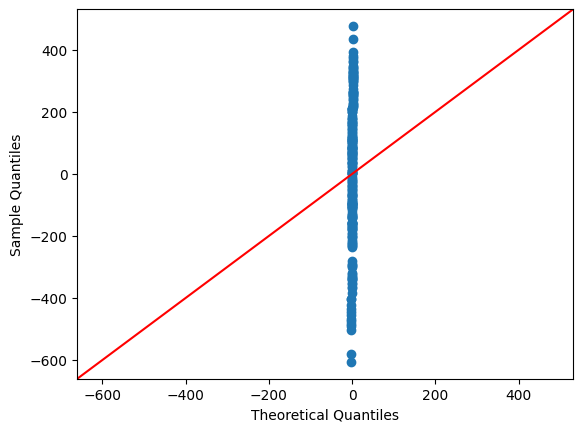

In [135]:
sm.qqplot(
    season_pol_2.resid,
    line='45'
)

py.show()

El gráfico QQPlot muestra que los residuales del modelo no siguen adecuadamente una distribución normal. Los puntos presentan una desviación importante respecto a la línea teórica de referencia, evidenciando que los errores no se distribuyen de manera gaussiana.

Esto sugiere que el supuesto de normalidad no se cumple completamente en los residuales del modelo de tendencia más estacionalidad.


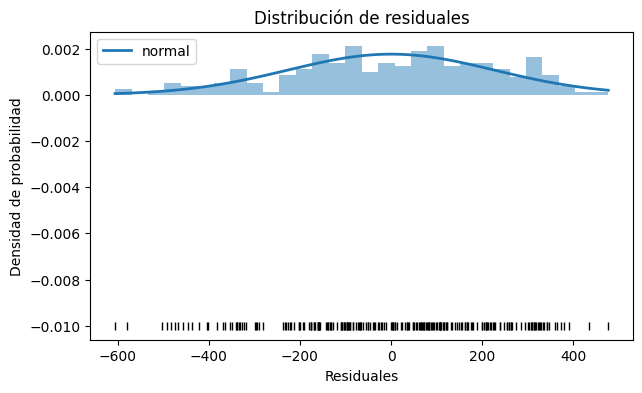

In [136]:
# Valores media y desviación estándar
mu, sigma = stats.norm.fit(season_pol_2.resid)

# Valores teóricos normales
x_hat = np.linspace(
    min(season_pol_2.resid),
    max(season_pol_2.resid),
    num=100
)

y_hat = stats.norm.pdf(x_hat, mu, sigma)

# Gráfica
fig, ax = plt.subplots(figsize=(7,4))

ax.plot(
    x_hat,
    y_hat,
    linewidth=2,
    label='normal'
)

ax.hist(
    season_pol_2.resid,
    density=True,
    bins=30,
    color='#3182bd',
    alpha=0.5
)

ax.plot(
    season_pol_2.resid,
    np.full_like(season_pol_2.resid, -0.01),
    '|k',
    markeredgewidth=1
)

ax.set_title('Distribución de residuales')

ax.set_xlabel('Residuales')

ax.set_ylabel('Densidad de probabilidad')

ax.legend()

El histograma de los residuales muestra una distribución aproximadamente centrada alrededor de cero y con cierta forma similar a una campana. Sin embargo, la distribución observada no coincide completamente con la curva normal teórica, evidenciando desviaciones y dispersión en algunos extremos.

Estos resultados complementan lo observado en el QQPlot y sugieren que los residuales presentan únicamente una aproximación parcial a la normalidad, por lo que el supuesto de distribución normal no se cumple completamente en el modelo.


In [137]:
# Shapiro-Wilk
stats.shapiro(season_pol_2.resid)

ShapiroResult(statistic=np.float64(0.9823804448800506), pvalue=np.float64(0.0072221585051047785))

In [138]:
# Jarque-Bera
stats.jarque_bera(season_pol_2.resid)

SignificanceResult(statistic=np.float64(6.062363741279992), pvalue=np.float64(0.04825856902270571))

Las pruebas de Shapiro-Wilk y Jarque-Bera presentan valores p menores a 0.05, por lo que se rechaza la hipótesis nula de normalidad en ambos casos. Estos resultados indican que los residuales del modelo no siguen una distribución normal.

Lo anterior confirma lo observado previamente en el QQPlot y en el histograma, donde se evidenciaban desviaciones respecto a la distribución normal teórica. A pesar de ello, el modelo continúa mostrando un buen desempeño predictivo en comparación con los demás modelos evaluados.


Evaluamos diferentes modelos de series de tiempo para pronosticar el número de ocupados en las 13 principales ciudades de Colombia. Inicialmente se analizaron modelos de tendencia lineal, tendencia cuadrática, estacionalidad y un modelo combinado de tendencia más estacionalidad.

Los resultados mostraron que el modelo combinado de tendencia y estacionalidad presentó el mejor desempeño entre los modelos de regresión evaluados, alcanzando el menor RMSE fuera de muestra y logrando capturar de manera más adecuada tanto la tendencia creciente como las fluctuaciones estacionales de la serie.

Sin embargo, al comparar estos resultados con los obtenidos en el ejercicio anterior, se observó que el modelo Holt-Winters multiplicativo continúa siendo el modelo con mejor capacidad predictiva, obteniendo un RMSE considerablemente menor. Esto evidencia que los métodos de suavización exponencial son más eficientes para modelar este tipo de series temporales.

Finalmente, el análisis de los residuales mostró que aún existen problemas de autocorrelación, heteroscedasticidad y desviaciones respecto a la normalidad, lo que indica que los modelos evaluados no logran capturar completamente toda la dinámica de la serie. A pesar de ello, los pronósticos obtenidos permiten identificar la tendencia general del comportamiento futuro del número de ocupados y constituyen una herramienta útil para el análisis económico y laboral.
